# Capítulo 4: Series de Tiempo. PROYECTO: USD/COP

> **Dora María Ballesteros**  
> *Investigación en Ciencia de Datos*  
> Primera edición, 2026  
> ISBN: 978-1-957395-63-0  
> 🔗 [**Consultar el libro en Editorial REDIPE**](https://editorial.redipe.org/index.php/1/catalog/book/245)

**Versión:** Septiembre de 2026

---

## Material complementario del libro

Este notebook acompaña el **Capítulo 4: Series de Tiempo** del libro *Investigación en Ciencia de Datos* y presenta un **ejemplo de desarrollo del Proyecto de Series de Tiempo**, utilizando la tasa de cambio **USD/COP** obtenida de **FRED – Federal Reserve Economic Data**.

El ejemplo integra **análisis temporal, dependencia temporal, Feature Engineering, construcción de la salida, modelamiento y experimentación**. Se utilizan técnicas de **Rolling, Lags y Expanding** para incorporar información temporal y evaluar su aporte al desempeño del modelo.

El objetivo será responder una pregunta:

¿La incorporación de información temporal mediante Feature Engineering permite mejorar la capacidad predictiva de un modelo aplicado a la serie USD/COP?

# **1. ANÁLISIS TEMPORAL DE LA SERIE**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargar dataset
usd_cop_df = pd.read_csv("USD_COP.csv")

# Convertir la variable temporal
usd_cop_df["observation_date"] = pd.to_datetime(
    usd_cop_df["observation_date"]
)

# Establecer la fecha como índice
usd_cop_df = usd_cop_df.set_index("observation_date")

# Ordenar cronológicamente
usd_cop_df = usd_cop_df.sort_index()

# Renombrar variable
usd_cop_df = usd_cop_df.rename(
    columns={"COLCCUSMA02STM": "USD_COP"}
)

usd_cop_df.head()

,USD_COP
observation_date,
2006-08-01,2388.823043
2006-09-01,2398.877619
2006-10-01,2363.934545
2006-11-01,2290.350909
2006-12-01,2260.696667


In [2]:
usd_cop_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 241 entries, 2006-08-01 to 2026-08-01
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   USD_COP  241 non-null    float64
dtypes: float64(1)
memory usage: 3.8 KB


In [3]:
print("Número de observaciones:", len(usd_cop_df))
print("Fecha inicial:", usd_cop_df.index.min())
print("Fecha final:", usd_cop_df.index.max())
print("\nValores faltantes:")
print(usd_cop_df.isnull().sum())

Número de observaciones: 241
Fecha inicial: 2006-08-01 00:00:00
Fecha final: 2026-08-01 00:00:00

Valores faltantes:
USD_COP    0
dtype: int64


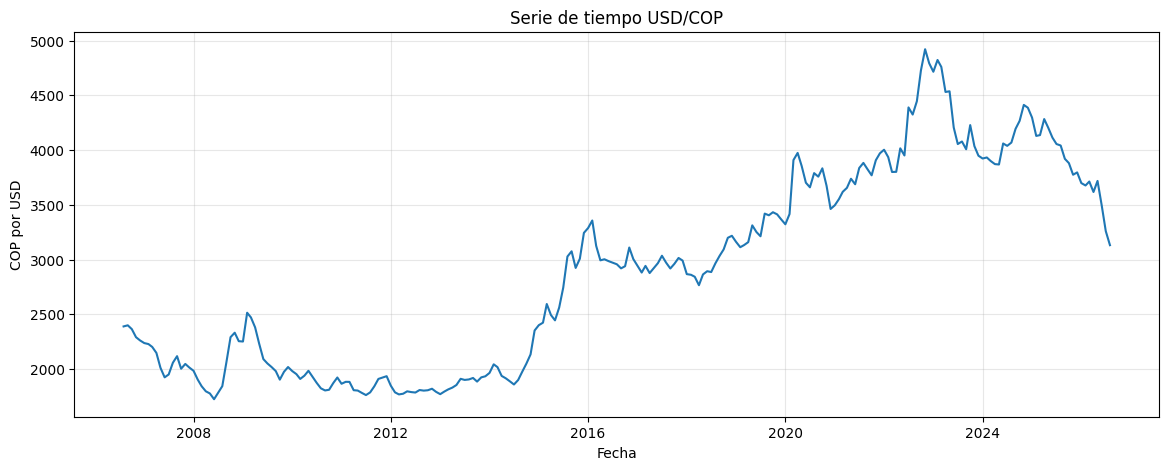

In [4]:
plt.figure(figsize=(14, 5))

plt.plot(
    usd_cop_df.index,
    usd_cop_df["USD_COP"]
)

plt.xlabel("Fecha")
plt.ylabel("COP por USD")
plt.title("Serie de tiempo USD/COP")
plt.grid(alpha=0.3)

plt.show()

In [5]:
# Media móvil de 12 meses
usd_cop_df["rolling_12"] = (
    usd_cop_df["USD_COP"]
    .rolling(window=12)
    .mean()
)

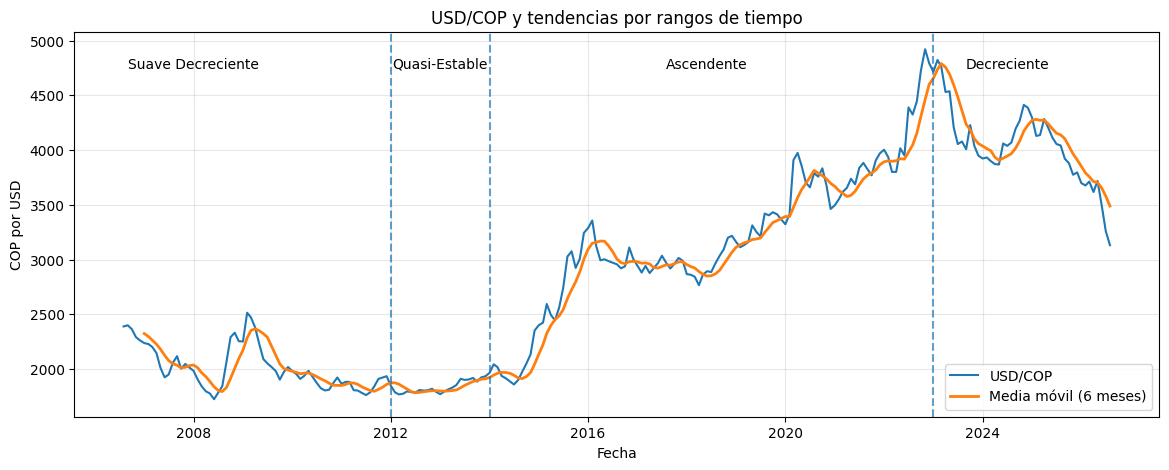

In [6]:
plt.figure(figsize=(14, 5))

usd_cop_df["rolling_6"] = (
    usd_cop_df["USD_COP"]
    .rolling(window=6)
    .mean()
)

plt.plot(
    usd_cop_df.index,
    usd_cop_df["USD_COP"],
    label="USD/COP"
)

plt.plot(
    usd_cop_df.index,
    usd_cop_df["rolling_6"],
    label="Media móvil (6 meses)",
    linewidth=2
)

# Límites de las zonas
for fecha in ["2012-01-01", "2014-01-01", "2023-01-01"]:
    plt.axvline(
        pd.Timestamp(fecha),
        linestyle="--",
        alpha=0.7
    )

# Etiquetas de las zonas
plt.text(pd.Timestamp("2008-01-01"), 4750, "Suave Decreciente", ha="center")
plt.text(pd.Timestamp("2013-01-01"), 4750, "Quasi-Estable", ha="center")
plt.text(pd.Timestamp("2018-06-01"), 4750, "Ascendente", ha="center")
plt.text(pd.Timestamp("2024-07-01"), 4750, "Decreciente", ha="center")

plt.xlabel("Fecha")
plt.ylabel("COP por USD")
plt.title("USD/COP y tendencias por rangos de tiempo")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 📈 Análisis de tendencia

- **2007–2012 – Tendencia suave decreciente:** disminución leve de la tasa USD/COP, con algunas fluctuaciones durante el periodo.

- **2012–2014 – Comportamiento relativamente estable:** baja variación de los valores, como se aprecia en la media móvil.

- **2014–2023 – Tendencia ascendente:** crecimiento general de la tasa USD/COP, con algunas fluctuaciones durante el periodo.

- **2023–2026 – Tendencia decreciente:** disminución de la tasa USD/COP después de alcanzar los valores máximos de la serie.

> 💡 **Conclusión:** la serie USD/COP presenta **cuatro zonas con comportamientos temporales diferentes**, identificadas a partir de la media móvil de 12 meses.

# **2. DEPENDENCIA TEMPORAL**

<Figure size 1400x500 with 0 Axes>

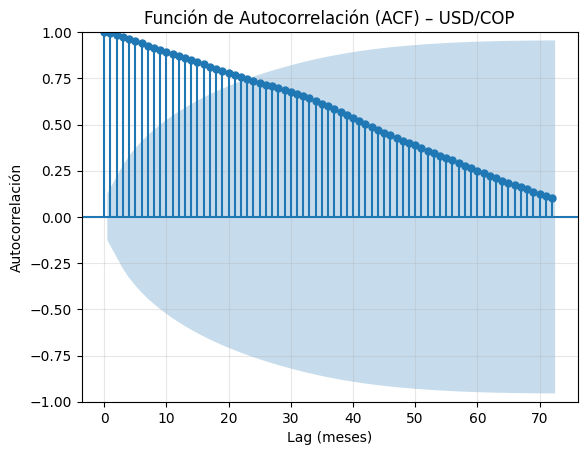

In [7]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plot_acf(
    usd_cop_df["USD_COP"].dropna(),
    lags=72,
    alpha=0.05
)

plt.xlabel("Lag (meses)")
plt.ylabel("Autocorrelación")
plt.title("Función de Autocorrelación (ACF) – USD/COP")
plt.grid(alpha=0.3)

plt.show()

### 🔄 Dependencia temporal

- Los primeros lags presentan una **alta autocorrelación**, mostrando una fuerte dependencia con los valores recientes.
- La autocorrelación **disminuye gradualmente**, aunque la dependencia se mantiene durante varios meses.
- A pesar de esta alta dependencia temporal, **no se detecta un patrón de ciclos**, ya que no se observan picos de autocorrelación que se repitan en intervalos regulares.


# **3. INGENIERÍA DE CARACTERÍSTICAS**

**3.1.  ROLLING**

In [8]:
# Ventanas Rolling
ventanas = [3, 6, 9, 12]

for ventana in ventanas:
    usd_cop_df[f"rolling_{ventana}"] = (
        usd_cop_df["USD_COP"]
        .shift(1)
        .rolling(window=ventana)
        .mean()
    )

rolling_df = usd_cop_df[
    [
        "rolling_3",
        "rolling_6",
        "rolling_9",
        "rolling_12"
    ]
].copy()

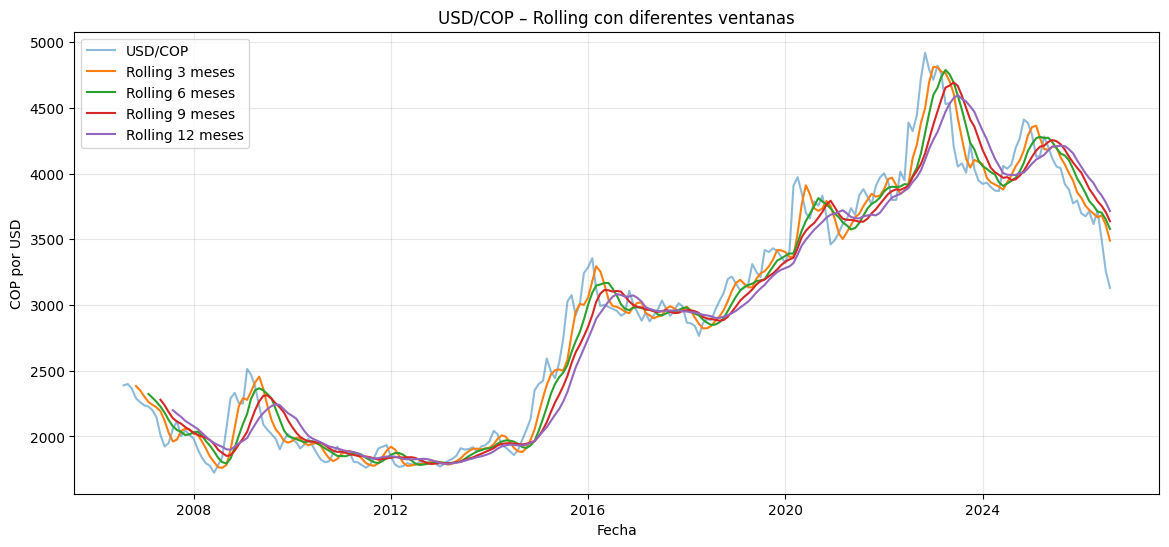

In [9]:
plt.figure(figsize=(14, 6))

# Serie original
plt.plot(
    usd_cop_df.index,
    usd_cop_df["USD_COP"],
    label="USD/COP",
    alpha=0.5
)

# Rolling
for ventana in ventanas:
    plt.plot(
        usd_cop_df.index,
        usd_cop_df[f"rolling_{ventana}"],
        label=f"Rolling {ventana} meses"
    )

plt.xlabel("Fecha")
plt.ylabel("COP por USD")
plt.title("USD/COP – Rolling con diferentes ventanas")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 📊 Análisis de Rolling

- Las ventanas pequeñas siguen más de cerca las **variaciones recientes** de la serie.
- Al aumentar la ventana, la serie presenta un **mayor suavizado** y representa cambios de más largo plazo.
- Las cuatro características contienen información temporal en **diferentes escalas**, que posteriormente será evaluada durante el modelamiento.

**3.2. LAG**

In [10]:
# Lags seleccionados
lags = [3, 6, 9, 12]

for lag in lags:
    usd_cop_df[f"lag_{lag}"] = (
        usd_cop_df["USD_COP"]
        .shift(lag)
    )

lags_df = usd_cop_df[
    [
        "lag_3",
        "lag_6",
        "lag_9",
        "lag_12"
    ]
].copy()

**3.2. EXPANDING**

In [11]:
# Feature Expanding
usd_cop_df["expanding_mean"] = (
    usd_cop_df["USD_COP"]
    .shift(1)
    .expanding()
    .mean()
)

In [12]:
# Dataset de expanding
expanding_df = usd_cop_df[
    ["expanding_mean"]
].copy()

expanding_df.head()

,expanding_mean
observation_date,
2006-08-01,NaN
2006-09-01,2388.823043
2006-10-01,2393.850331
2006-11-01,2383.878403
2006-12-01,2360.496529


# **4. CONSTRUCCIÓN DE LA SALIDA**

In [13]:
# Valor del USD/COP en el siguiente mes
usd_cop_df["USD_COP_next"] = (
    usd_cop_df["USD_COP"]
    .shift(-1)
)

In [14]:
# Umbral para definir el incremento
# Ejemplos:
# 0     -> cualquier incremento
# 0.005 -> incremento superior al 0.5 %
# 0.01  -> incremento superior al 1 %

umbral = 0

# Crear DataFrame con el mismo índice de la serie original
target_df = pd.DataFrame(index=usd_cop_df.index)

# Valor del siguiente periodo
target_df["USD_COP_t+1"] = usd_cop_df["USD_COP"].shift(-1)

# Variable objetivo
target_df["target"] = (
    target_df["USD_COP_t+1"]
    > usd_cop_df["USD_COP"] * (1 + umbral)
).astype(float)

# El último dato no tiene valor futuro y, por tanto, no tiene target
target_df.loc[target_df.index[-1], "target"] = np.nan

target_df.head()

,USD_COP_t+1,target
observation_date,,
2006-08-01,2398.877619,1.0
2006-09-01,2363.934545,0.0
2006-10-01,2290.350909,0.0
2006-11-01,2260.696667,0.0
2006-12-01,2236.755217,0.0


In [15]:
print(f"Umbral utilizado: {umbral:.2%}")

Umbral utilizado: 0.00%


In [16]:
target_df["target"].value_counts()

,count
target,
0.0,127
1.0,113


In [17]:
print("Distribución porcentual del target:")
print(target_df["target"].value_counts(normalize=True).mul(100).round(2))

Distribución porcentual del target:
target
0.0    52.92
1.0    47.08
Name: proportion, dtype: float64


### 🎯 Construcción de la salida

La serie original no contiene una variable objetivo. Por esta razón, se construye una salida binaria que indica si el valor de la serie en el siguiente periodo supera el valor actual en una proporción definida mediante un **umbral $u$**.

La variable objetivo se define como:

$$
y_t =
\begin{cases}
1, & P_{t+1} > P_t(1+u) \\
0, & P_{t+1} \leq P_t(1+u)
\end{cases}
$$

donde $u$ corresponde al umbral definido para el experimento.

Por tanto:

- **1:** el valor de la serie en el siguiente periodo aumenta más que el umbral establecido.
- **0:** el valor de la serie en el siguiente periodo no supera el umbral establecido.

# **5.  MODELAMIENTO Y EXPERIMENTACIÓN**

### 📂 Organización de los datasets

`usd_cop_df` → serie original.

1. `rolling_df` → únicamente features **Rolling**.
2. `lags_df` → únicamente features **Lag**.
3. `expanding_df` → únicamente feature **Expanding**.
4. `target_df` → únicamente la **salida**.

In [18]:
# Índice común para todos los experimentos
indice_comun = (
    usd_cop_df[["USD_COP"]]
    .dropna()
    .index
    .intersection(rolling_df.dropna().index)
    .intersection(lags_df.dropna().index)
    .intersection(expanding_df.dropna().index)
    .intersection(target_df.dropna().index)
)

# División temporal 70 % - 30 %
split = int(len(indice_comun) * 0.7)

train_index = indice_comun[:split]
test_index = indice_comun[split:]

print("Entrenamiento:", train_index.min(), "→", train_index.max())
print("Prueba:", test_index.min(), "→", test_index.max())
print("Observaciones Train:", len(train_index))
print("Observaciones Test:", len(test_index))

Entrenamiento: 2007-08-01 00:00:00 → 2020-10-01 00:00:00
Prueba: 2020-11-01 00:00:00 → 2026-07-01 00:00:00
Observaciones Train: 159
Observaciones Test: 69


In [19]:
print("Original: ",
      usd_cop_df[["USD_COP"]].dropna().index.min())

print("Rolling:  ",
      rolling_df.dropna().index.min())

print("Lags:     ",
      lags_df.dropna().index.min())

print("Expanding:",
      expanding_df.dropna().index.min())

print("Target:   ",
      target_df.dropna().index.min())

print("\nÍndice común:", indice_comun.min())
print("Número de datos:", len(indice_comun))

Original:  2006-08-01 00:00:00
Rolling:   2007-08-01 00:00:00
Lags:      2007-08-01 00:00:00
Expanding: 2006-09-01 00:00:00
Target:    2006-08-01 00:00:00

Índice común: 2007-08-01 00:00:00
Número de datos: 228


In [20]:
print(
    "Original:",
    usd_cop_df[["USD_COP"]].dropna().index.min()
)

Original: 2006-08-01 00:00:00


In [21]:
print("Distribución Train (%):")
print(
    target_df.loc[train_index, "target"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\nDistribución Test (%):")
print(
    target_df.loc[test_index, "target"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

Distribución Train (%):
target
0.0    50.314465
1.0    49.685535
Name: proportion, dtype: float64

Distribución Test (%):
target
0.0    55.072464
1.0    44.927536
Name: proportion, dtype: float64


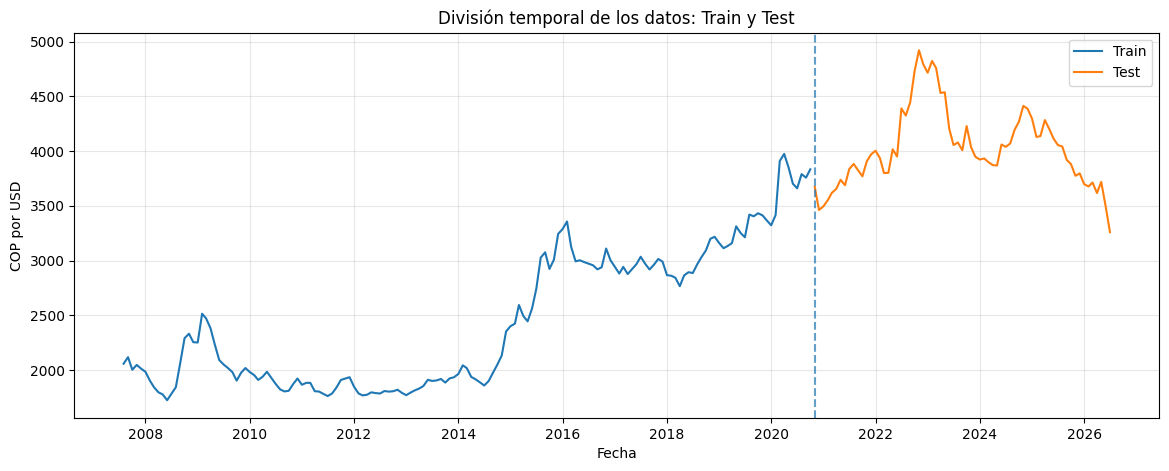

In [22]:
plt.figure(figsize=(14, 5))

# Train
plt.plot(
    train_index,
    usd_cop_df.loc[train_index, "USD_COP"],
    label="Train"
)

# Test
plt.plot(
    test_index,
    usd_cop_df.loc[test_index, "USD_COP"],
    label="Test"
)

# Línea de separación
plt.axvline(
    test_index[0],
    linestyle="--",
    alpha=0.7
)

plt.xlabel("Fecha")
plt.ylabel("COP por USD")
plt.title("División temporal de los datos: Train y Test")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**División temporal de los datos**

Se utiliza una división temporal de **70 % para entrenamiento y 30 % para prueba**, manteniendo el orden cronológico de las observaciones.

- **Train:** agosto de 2007 – octubre de 2020.
- **Test:** noviembre de 2020 – julio de 2026.
- La distribución de clases en Train es aproximadamente **50.3 % (clase 0) / 49.7 % (clase 1)**.
- En Test, la distribución es aproximadamente **55 % (clase 0) / 45 % (clase 1)**.

Esta división permite evaluar el modelo en un periodo que comprende parte de la tendencia creciente y la tendencia decreciente de la serie.

# **5.1. MODELO BASELINE**

In [23]:
# Feature del modelo Baseline
X_baseline = usd_cop_df[["USD_COP"]]

# Train y Test
X_train = X_baseline.loc[train_index]
X_test = X_baseline.loc[test_index]

y_train = target_df.loc[train_index, "target"].astype(int)
y_test = target_df.loc[test_index, "target"].astype(int)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (159, 1)
Test: (69, 1)


In [24]:
from sklearn.ensemble import RandomForestClassifier

modelo_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_baseline.fit(X_train, y_train)

# Predicción
y_pred_baseline = modelo_baseline.predict(X_test)

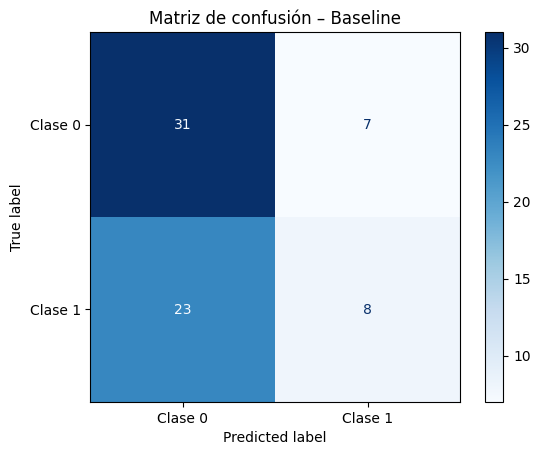

Accuracy: 0.5652

Métricas por clase:
              precision    recall  f1-score   support

     Clase 0     0.5741    0.8158    0.6739        38
     Clase 1     0.5333    0.2581    0.3478        31

    accuracy                         0.5652        69
   macro avg     0.5537    0.5369    0.5109        69
weighted avg     0.5558    0.5652    0.5274        69



In [25]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report
)

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_baseline,
    display_labels=["Clase 0", "Clase 1"],
    cmap="Blues"
)

plt.title("Matriz de confusión – Baseline")
plt.show()

# Métricas
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")

print("\nMétricas por clase:")
print(
    classification_report(
        y_test,
        y_pred_baseline,
        target_names=["Clase 0", "Clase 1"],
        digits=4,
        zero_division=0
    )
)

### 📊 Resultados del Baseline

- El modelo clasifica correctamente **31 de 38 observaciones de la Clase 0**.
- Para la **Clase 1**, identifica correctamente **8 de 31 observaciones**.
- El modelo presenta un desempeño considerablemente mayor para la Clase 0, con un F1-score de 0.6739 frente a 0.3478 para la Clase 1.

# **5.2. MODELO FEATURE ORIGINAL + 4 FEATURES DE ROLLING**

In [26]:
# Feature original + 4 features Rolling
X_rolling = pd.concat(
    [
        usd_cop_df[["USD_COP"]],
        rolling_df
    ],
    axis=1
)

X_rolling.head()

,USD_COP,rolling_3,rolling_6,rolling_9,rolling_12
observation_date,,,,,
2006-08-01,2388.823043,NaN,NaN,NaN,NaN
2006-09-01,2398.877619,NaN,NaN,NaN,NaN
2006-10-01,2363.934545,NaN,NaN,NaN,NaN
2006-11-01,2290.350909,2383.878403,NaN,NaN,NaN
2006-12-01,2260.696667,2351.054358,NaN,NaN,NaN


In [27]:
# Train y Test
X_train = X_rolling.loc[train_index]
X_test = X_rolling.loc[test_index]

y_train = target_df.loc[train_index, "target"].astype(int)
y_test = target_df.loc[test_index, "target"].astype(int)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (159, 5)
Test: (69, 5)


In [28]:
modelo_rolling = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rolling.fit(X_train, y_train)

# Predicción
y_pred_rolling = modelo_rolling.predict(X_test)

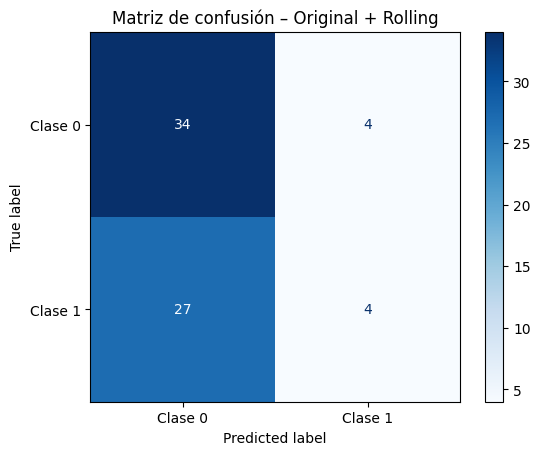

Accuracy: 0.5507

Métricas por clase:
              precision    recall  f1-score   support

     Clase 0     0.5574    0.8947    0.6869        38
     Clase 1     0.5000    0.1290    0.2051        31

    accuracy                         0.5507        69
   macro avg     0.5287    0.5119    0.4460        69
weighted avg     0.5316    0.5507    0.4704        69



In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rolling,
    display_labels=["Clase 0", "Clase 1"],
    cmap="Blues"
)

plt.title("Matriz de confusión – Original + Rolling")
plt.show()

print(f"Accuracy: {accuracy_score(y_test, y_pred_rolling):.4f}")

print("\nMétricas por clase:")
print(
    classification_report(
        y_test,
        y_pred_rolling,
        target_names=["Clase 0", "Clase 1"],
        digits=4,
        zero_division=0
    )
)

### 📊 Resultados Original + Rolling

- La detección de la **Clase 0 mejora** respecto a Baseline, pasando de 31 a 34 observaciones correctamente clasificadas.
- Para la **Clase 1**, los aciertos disminuyen de 8 a 4 observaciones.
- La incorporación de los features Rolling modifica el comportamiento del modelo, pero **no mejora su desempeño global respecto al Baseline**.

# **5.3. MODELO FEATURE ORIGINAL + 4 FEATURES DE LAG**

In [30]:
# Feature original + 4 features Lag
X_lags = pd.concat(
    [
        usd_cop_df[["USD_COP"]],
        lags_df
    ],
    axis=1
)

X_lags.head()

,USD_COP,lag_3,lag_6,lag_9,lag_12
observation_date,,,,,
2006-08-01,2388.823043,NaN,NaN,NaN,NaN
2006-09-01,2398.877619,NaN,NaN,NaN,NaN
2006-10-01,2363.934545,NaN,NaN,NaN,NaN
2006-11-01,2290.350909,2388.823043,NaN,NaN,NaN
2006-12-01,2260.696667,2398.877619,NaN,NaN,NaN


In [31]:
# Train y Test
X_train = X_lags.loc[train_index]
X_test = X_lags.loc[test_index]

y_train = target_df.loc[train_index, "target"].astype(int)
y_test = target_df.loc[test_index, "target"].astype(int)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (159, 5)
Test: (69, 5)


In [32]:
modelo_lags = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_lags.fit(X_train, y_train)

# Predicción
y_pred_lags = modelo_lags.predict(X_test)

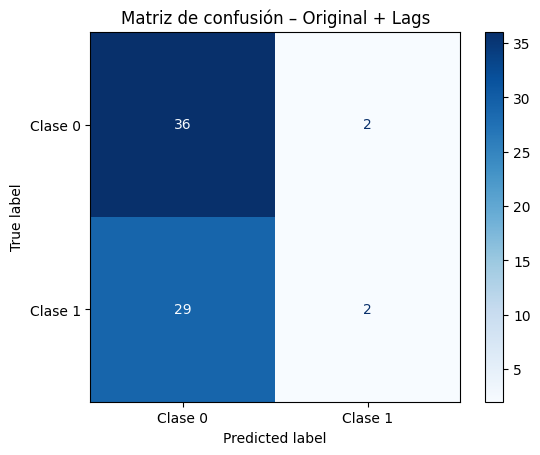

Accuracy: 0.5507

Métricas por clase:
              precision    recall  f1-score   support

     Clase 0     0.5538    0.9474    0.6990        38
     Clase 1     0.5000    0.0645    0.1143        31

    accuracy                         0.5507        69
   macro avg     0.5269    0.5059    0.4067        69
weighted avg     0.5297    0.5507    0.4363        69



In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lags,
    display_labels=["Clase 0", "Clase 1"],
    cmap="Blues"
)

plt.title("Matriz de confusión – Original + Lags")
plt.show()

print(f"Accuracy: {accuracy_score(y_test, y_pred_lags):.4f}")

print("\nMétricas por clase:")
print(
    classification_report(
        y_test,
        y_pred_lags,
        target_names=["Clase 0", "Clase 1"],
        digits=4,
        zero_division=0
    )
)

### 📊 Resultados Original + Lags

- La detección de la **Clase 0 mejora** respecto a Baseline, pasando de 31 a 36 observaciones correctamente clasificadas.
- Para la **Clase 1**, los aciertos disminuyen de 8 a 2 observaciones.
- Aunque la accuracy es similar a Original + Rolling, el modelo presenta una mayor tendencia a predecir la Clase 0, alcanzando un recall de 0.9474 para esta clase y únicamente 0.0645 para la Clase 1.

# **5.4 Original + Expanding**

In [34]:
# Feature original + feature Expanding
X_expanding = pd.concat(
    [
        usd_cop_df[["USD_COP"]],
        expanding_df
    ],
    axis=1
)

X_expanding.head()

,USD_COP,expanding_mean
observation_date,,
2006-08-01,2388.823043,NaN
2006-09-01,2398.877619,2388.823043
2006-10-01,2363.934545,2393.850331
2006-11-01,2290.350909,2383.878403
2006-12-01,2260.696667,2360.496529


In [35]:
# Train y Test
X_train = X_expanding.loc[train_index]
X_test = X_expanding.loc[test_index]

y_train = target_df.loc[train_index, "target"].astype(int)
y_test = target_df.loc[test_index, "target"].astype(int)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (159, 2)
Test: (69, 2)


In [36]:
modelo_expanding = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_expanding.fit(X_train, y_train)

# Predicción
y_pred_expanding = modelo_expanding.predict(X_test)

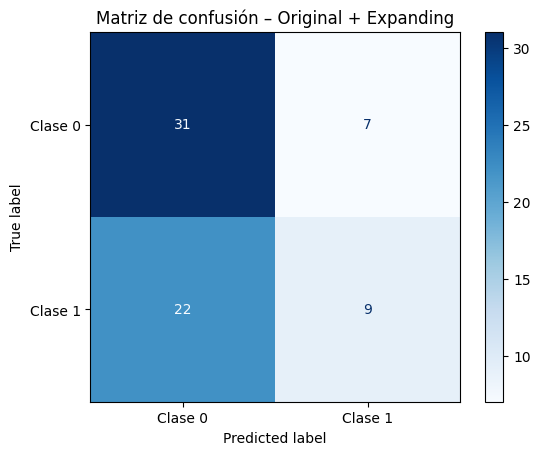

Accuracy: 0.5797

Métricas por clase:
              precision    recall  f1-score   support

     Clase 0     0.5849    0.8158    0.6813        38
     Clase 1     0.5625    0.2903    0.3830        31

    accuracy                         0.5797        69
   macro avg     0.5737    0.5531    0.5321        69
weighted avg     0.5748    0.5797    0.5473        69



In [37]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_expanding,
    display_labels=["Clase 0", "Clase 1"],
    cmap="Blues"
)

plt.title("Matriz de confusión – Original + Expanding")
plt.show()

print(f"Accuracy: {accuracy_score(y_test, y_pred_expanding):.4f}")

print("\nMétricas por clase:")
print(
    classification_report(
        y_test,
        y_pred_expanding,
        target_names=["Clase 0", "Clase 1"],
        digits=4,
        zero_division=0
    )
)

# 📊 Resultados Original + Expanding

- Respecto al modelo "Baseline", empata en la detección de la **Clase 0**, pero mejora en 1 detección, pasando de 8 a 9, en la **Clase 1**.
- Entre los modelos evaluados hasta este punto, Original + Expanding presenta el mayor accuracy y el mayor F1-score para la Clase 1.

# **5.5 Original + TODOS LOS NUEVOS FEATURES**

In [38]:
# Feature original + todos los features temporales
X_integracion = pd.concat(
    [
        usd_cop_df[["USD_COP"]],
        rolling_df,
        lags_df,
        expanding_df
    ],
    axis=1
)

X_integracion.head()

,USD_COP,rolling_3,rolling_6,rolling_9,rolling_12,lag_3,lag_6,lag_9,lag_12,expanding_mean
observation_date,,,,,,,,,,
2006-08-01,2388.823043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-09-01,2398.877619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2388.823043
2006-10-01,2363.934545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2393.850331
2006-11-01,2290.350909,2383.878403,NaN,NaN,NaN,2388.823043,NaN,NaN,NaN,2383.878403
2006-12-01,2260.696667,2351.054358,NaN,NaN,NaN,2398.877619,NaN,NaN,NaN,2360.496529


In [39]:
# Train y Test
X_train = X_integracion.loc[train_index]
X_test = X_integracion.loc[test_index]

y_train = target_df.loc[train_index, "target"].astype(int)
y_test = target_df.loc[test_index, "target"].astype(int)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (159, 10)
Test: (69, 10)


In [40]:
modelo_integracion = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_integracion.fit(X_train, y_train)

# Predicción
y_pred_integracion = modelo_integracion.predict(X_test)

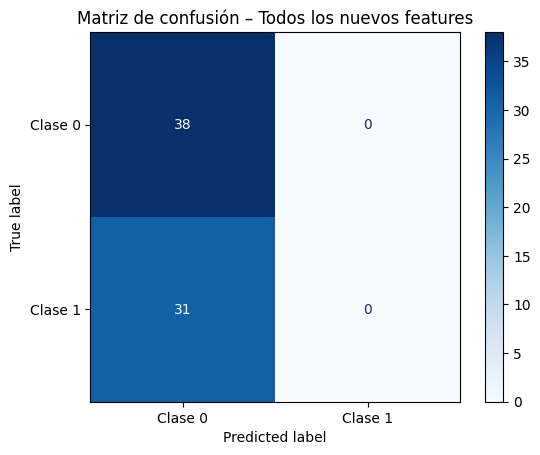

Accuracy: 0.5507

Métricas por clase:
              precision    recall  f1-score   support

     Clase 0     0.5507    1.0000    0.7103        38
     Clase 1     0.0000    0.0000    0.0000        31

    accuracy                         0.5507        69
   macro avg     0.2754    0.5000    0.3551        69
weighted avg     0.3033    0.5507    0.3912        69



In [41]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_integracion,
    display_labels=["Clase 0", "Clase 1"],
    cmap="Blues"
)

plt.title("Matriz de confusión – Todos los nuevos features")
plt.show()

print(f"Accuracy: {accuracy_score(y_test, y_pred_integracion):.4f}")

print("\nMétricas por clase:")
print(
    classification_report(
        y_test,
        y_pred_integracion,
        target_names=["Clase 0", "Clase 1"],
        digits=4,
        zero_division=0
    )
)

### 📊 Resultados Original + TODOS los nuevos features

- El modelo clasifica todas las observaciones como Clase 0. Aunque alcanza una accuracy de 0.5507, presenta recall y F1-score iguales a 0 para la Clase 1. Este resultado evidencia que la accuracy, analizada de forma aislada, no permite evaluar adecuadamente el desempeño del modelo.


In [42]:
# Importancia de los features del modelo de integración
importancia_features = pd.DataFrame({
    "Feature": X_integracion.columns,
    "Importancia": modelo_integracion.feature_importances_
})

# Ordenar de mayor a menor importancia
importancia_features = importancia_features.sort_values(
    by="Importancia",
    ascending=False
)

importancia_features

,Feature,Importancia
6,lag_6,0.121184
9,expanding_mean,0.120262
8,lag_12,0.109381
1,rolling_3,0.107908
3,rolling_9,0.103131
7,lag_9,0.092530
4,rolling_12,0.089184
5,lag_3,0.088275
2,rolling_6,0.085965
0,USD_COP,0.082180


### 📊 Importancia de Features

A partir del modelo que integra todos los features se obtiene su importancia relativa.

- **Lag:** `lag_6` presenta la mayor importancia entre los features Lag.
- **Rolling:** `rolling_3` presenta la mayor importancia entre los features Rolling.
- **Expanding:** se utiliza `expanding_mean`, único feature construido con esta técnica.

A partir de estos resultados, se seleccionan `rolling_3`, `lag_6` y `expanding_mean` para construir el último modelo, **sin incluir el feature original `USD_COP`**.

# **5.6 EL MEJOR ROLLING, EL MEJOR LAG, EXPANGING, SIN ORIGINAL**

In [43]:
# Features seleccionados
X_seleccion = pd.concat(
    [
        rolling_df[["rolling_3"]],
        lags_df[["lag_6"]],
        expanding_df[["expanding_mean"]]
    ],
    axis=1
)

X_seleccion.head()

,rolling_3,lag_6,expanding_mean
observation_date,,,
2006-08-01,NaN,NaN,NaN
2006-09-01,NaN,NaN,2388.823043
2006-10-01,NaN,NaN,2393.850331
2006-11-01,2383.878403,NaN,2383.878403
2006-12-01,2351.054358,NaN,2360.496529


In [44]:
# Train y Test
X_train = X_seleccion.loc[train_index]
X_test = X_seleccion.loc[test_index]

y_train = target_df.loc[train_index, "target"].astype(int)
y_test = target_df.loc[test_index, "target"].astype(int)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (159, 3)
Test: (69, 3)


In [45]:
modelo_seleccion = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_seleccion.fit(X_train, y_train)

# Predicción
y_pred_seleccion = modelo_seleccion.predict(X_test)

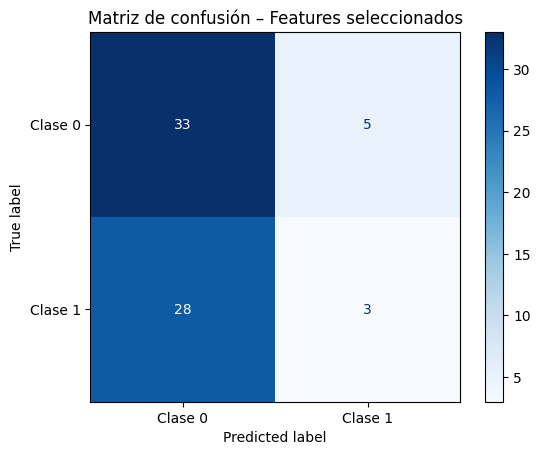

Accuracy: 0.5217

Métricas por clase:
              precision    recall  f1-score   support

     Clase 0     0.5410    0.8684    0.6667        38
     Clase 1     0.3750    0.0968    0.1538        31

    accuracy                         0.5217        69
   macro avg     0.4580    0.4826    0.4103        69
weighted avg     0.4664    0.5217    0.4363        69



In [46]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_seleccion,
    display_labels=["Clase 0", "Clase 1"],
    cmap="Blues"
)

plt.title("Matriz de confusión – Features seleccionados")
plt.show()

print(f"Accuracy: {accuracy_score(y_test, y_pred_seleccion):.4f}")

print("\nMétricas por clase:")
print(
    classification_report(
        y_test,
        y_pred_seleccion,
        target_names=["Clase 0", "Clase 1"],
        digits=4,
        zero_division=0
    )
)